# Egypt Real Estate — Price Prediction

In this notebook we build machine learning models that predict the **price per square meter** for Egyptian property listings.

We also train a classifier to decide whether a listing is for **Buy** or **Rent**.

Here is what we do step by step:

1. Load the cleaned data and add new useful columns
2. Remove extreme values (outliers) from the data
3. Study how features relate to the price (correlation analysis)
4. Train four regression models and compare them
5. Classify listings as Buy or Rent
6. Save predictions to disk

**Dataset:** `egypt_re_clean.csv` — 35,830 listings scraped in February 2026.

## Step 0 — Import Libraries

We collect all imports in one place. Run this cell first before anything else.

In [1]:
import warnings, os
warnings.filterwarnings('ignore')   # hide unimportant warning messages

# Math and data tools
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Statistics
from scipy import stats as scipy_stats
from scipy.stats import pointbiserialr
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Machine learning — building blocks
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    accuracy_score, f1_score, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

# Gradient boosting models
from xgboost import XGBRegressor, XGBClassifier
import lightgbm as lgb

# Fix the random seed so results are reproducible
SEED = 42
RANDOM_STATE = SEED
np.random.seed(SEED)

# Set a clean visual style for all charts
sns.set_theme(style='whitegrid', palette='muted')

print('All libraries loaded successfully!')

All libraries loaded successfully!


## Step 1 — Load the Data

Change `DATA_PATH` to the location of your `egypt_re_clean.csv` file.

The dataset has **35,830 rows** and **70 columns** after cleaning.

In [2]:
# Change this path to where you saved the CSV file
DATA_PATH = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_clean.csv'

df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# Print the size of the dataset
print(f'Rows: {df_raw.shape[0]:,}   Columns: {df_raw.shape[1]}')

# Show the first 3 rows to check the data looks right
df_raw.head(3)

Rows: 36,870   Columns: 70


,listing_id,category,property_type,offering_type,completion_status,price_egp,price_period,price_currency,location_full,city,...,amen_view_of_water,amen_private_garden,amen_maids_room,amen_private_pool,amen_networked,amen_dining_in_building,price_per_sqm,total_rooms,is_furnished_binary,amenity_count
0,HYEPN5XPWQT7K05K4ST7EDWW5R,rent,Apartment,Rent,Unknown,75000.0,monthly,EGP,"Villette, 5th Settlement Compounds, The 5th Se...",Cairo,...,1,0,0,0,0,0,520.833333,4.0,1,13
1,9Q295E8B6ET3V30Z31925BR6ZG,rent,Apartment,Rent,Unknown,50000.0,monthly,EGP,"New Giza, Cairo Alexandria Desert Road, 6 Octo...",Giza,...,0,0,0,0,0,0,255.102041,4.0,0,4
2,R9PTSC3V5RZ77ZT9X69TBE1PEC,rent,Townhouse,Rent,Unknown,120000.0,monthly,EGP,"Joulz, Cairo Alexandria Desert Road, 6 October...",Giza,...,1,1,1,0,0,0,375.000000,10.0,1,16


## Step 2 — Feature Engineering

Raw data alone is often not enough. We create new columns that help the model understand the listings better.

| New column | What it means |
|---|---|
| `log_area` | Log of the area — reduces the effect of very large properties |
| `bed_bath_ratio` | Bedrooms divided by bathrooms |
| `area_per_room` | Average square meters per room |
| `amenity_count` | How many amenities the listing has |
| `completion_score` | 0 = off-plan, 1 = in progress, 2 = completed |
| `days_listed` | How many days since the listing was published |

We never change the target column (`price_egp`) here.

In [3]:
def build_features(df):
    df = df.copy()   # work on a copy so we don't change the original

    # Make sure key columns are numeric (not stored as text)
    for col in ['bedrooms', 'bathrooms', 'price_egp', 'area_value', 'images_count']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # --- Size features ---
    df['log_area']       = np.log1p(df['area_value'].clip(lower=0))   # log(area + 1)
    df['bed_bath_ratio'] = (df['bedrooms'] / df['bathrooms'].replace(0, 1)).round(2)
    df['total_rooms']    = df['bedrooms'].fillna(0) + df['bathrooms'].fillna(0)
    df['area_per_room']  = df['area_value'] / df['total_rooms'].replace(0, 1)
    df['area_x_beds']    = df['area_value'] * df['bedrooms'].fillna(0)

    # --- Amenities ---
    if 'amenities' in df.columns:
        # Count how many amenities are listed (separated by '|')
        df['amenity_count'] = df['amenities'].apply(
            lambda x: len(str(x).split('|')) if pd.notna(x) and x != '' else 0
        )
        # Create a 1/0 flag for each common amenity
        for name, col_name in [
            ('Pool', 'has_pool'), ('Gym', 'has_gym'), ('Security', 'has_security'),
            ('Parking', 'has_parking'), ('Garden', 'has_garden'), ('Balcony', 'has_balcony'),
            ('Private Pool', 'has_private_pool'), ('A/C', 'has_ac'),
        ]:
            df[col_name] = df['amenities'].apply(
                lambda x, a=name: int(str(x).lower().find(a.lower()) >= 0)
            )

    # --- Furnished flag ---
    if 'is_furnished_binary' in df.columns:
        df['is_furnished'] = df['is_furnished_binary'].astype(int)
    elif 'furnished' in df.columns:
        df['is_furnished'] = (df['furnished'].astype(str).str.strip().str.lower().isin(
            ['yes', 'furnished', 'fully furnished']
        )).astype(int)

    # --- Large area flag: 1 if property is in the top 25% by area ---
    if 'area_value' in df.columns:
        q75 = df['area_value'].quantile(0.75)
        df['area_flag'] = (df['area_value'] >= q75).astype(int)

    # --- Completion score: convert text status to number ---
    if 'completion_status' in df.columns:
        cmap = {'completed': 2, 'completed_primary': 2, 'off_plan': 0, 'off_plan_primary': 0}
        df['completion_score'] = df['completion_status'].map(cmap).fillna(1)

    # --- Installments flag ---
    if 'payment_method' in df.columns:
        df['has_installments'] = df['payment_method'].str.contains(
            'installments', case=False, na=False
        ).astype(int)

    # --- Days since listed ---
    if 'listed_date' in df.columns:
        ref = pd.Timestamp('2026-03-05', tz='UTC')
        df['listed_date'] = pd.to_datetime(df['listed_date'], errors='coerce', utc=True)
        df['days_listed'] = (ref - df['listed_date']).dt.days.fillna(-1).astype(int)

    return df


df = build_features(df_raw)
print(f'After feature engineering: {df.shape[0]:,} rows   {df.shape[1]} columns')

After feature engineering: 36,870 rows   86 columns


## Step 3 — Remove Outliers

Outliers are values that are unrealistically high or low. They confuse the model.

We use two methods together:
- **Z-score > 3**: the value is more than 3 standard deviations away from the mean
- **IQR fence**: the value is too far above Q3 or below Q1

If a row is flagged by either method, we remove it.

The charts below show the data before and after cleaning.

In [4]:
# Columns we want to clean for outliers
OUTLIER_COLS = [c for c in ['price_egp', 'area_value'] if c in df.columns]
Z_THRESH = 3   # flag anything more than 3 std deviations from the mean

df['is_outlier'] = False   # start with no rows flagged
rows = []

for col in OUTLIER_COLS:
    s = df[col].dropna()
    n = len(s)

    # Method 1: Z-score
    z   = np.abs(scipy_stats.zscore(s))
    z_i = s.index[z > Z_THRESH]

    # Method 2: IQR fence
    Q1, Q3 = s.quantile([0.25, 0.75])
    IQR = Q3 - Q1
    iq_i = df.index[
        (df[col].notna()) & ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR))
    ]

    # Union: flag row if caught by either method
    combo = z_i.union(iq_i)
    df.loc[combo, 'is_outlier'] = True

    rows.append({
        'column':        col,
        'z_outliers':    len(z_i),
        'iqr_outliers':  len(iq_i),
        'total_flagged': len(combo),
        'pct':           f'{len(combo) / n * 100:.2f}%',
        'min_val':       f'{df.loc[combo, col].min():,.1f}' if len(combo) else 'N/A',
        'max_val':       f'{df.loc[combo, col].max():,.1f}' if len(combo) else 'N/A',
    })

report = pd.DataFrame(rows)
total = df['is_outlier'].sum()
print(f'Flagged as outliers: {total:,} rows ({total / len(df) * 100:.2f}%)')
display(report)

Flagged as outliers: 3,414 rows (9.26%)


,column,z_outliers,iqr_outliers,total_flagged,pct,min_val,max_val
0,price_egp,824,2212,2212,6.00%,"20,469,400.0","34,500,000.0"
1,area_value,513,1644,1644,4.46%,369.0,"1,683.0"


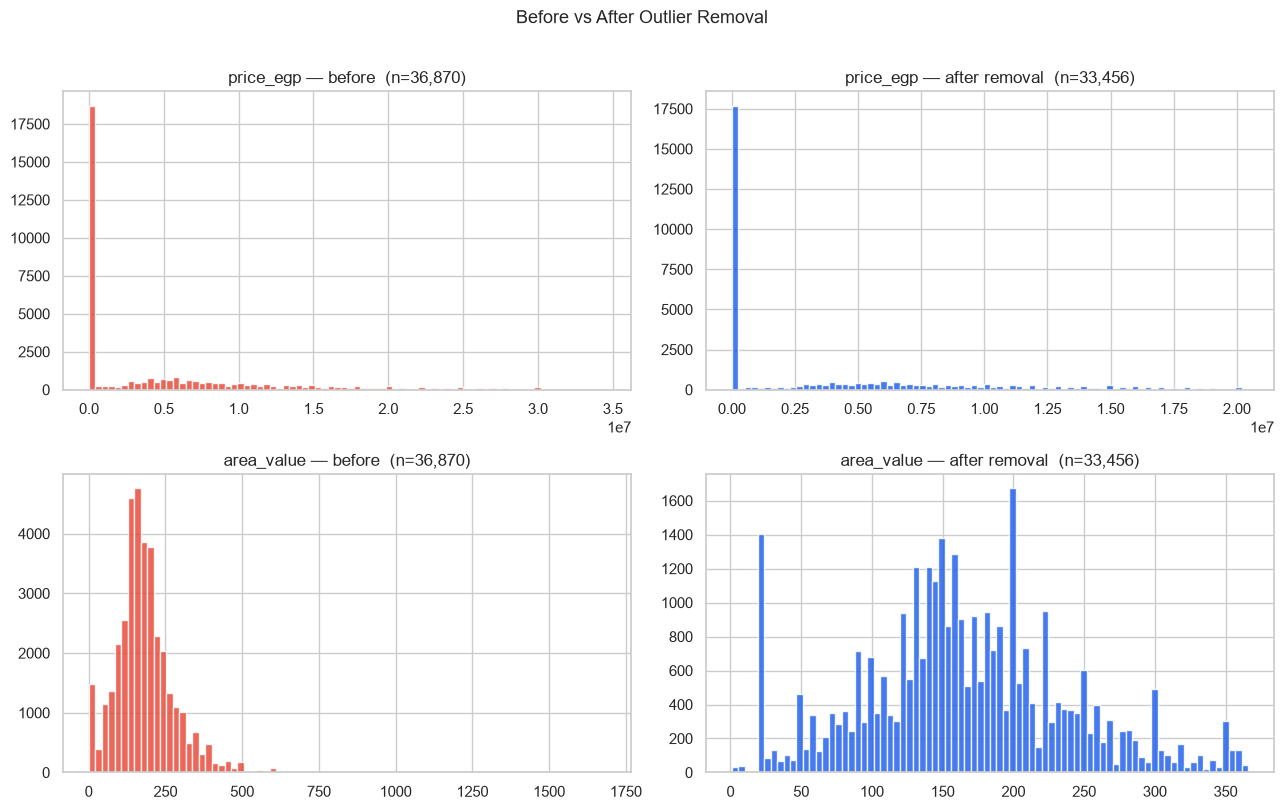

Rows removed : 3,414
Clean dataset: 33,456 rows


In [5]:
# Keep only the rows that are NOT outliers
df_clean = df[~df['is_outlier']].copy()

# Plot before vs after to visually confirm the cleanup
fig, axes = plt.subplots(len(OUTLIER_COLS), 2, figsize=(13, 4 * len(OUTLIER_COLS)))
if len(OUTLIER_COLS) == 1:
    axes = [axes]

for i, col in enumerate(OUTLIER_COLS):
    # Before: red histogram
    axes[i][0].hist(df[col].dropna(), bins=80, color='#e74c3c', edgecolor='white', alpha=0.85)
    axes[i][0].set_title(f'{col} — before  (n={df[col].notna().sum():,})')

    # After: blue histogram
    axes[i][1].hist(df_clean[col].dropna(), bins=80, color='#2563EB', edgecolor='white', alpha=0.85)
    axes[i][1].set_title(f'{col} — after removal  (n={df_clean[col].notna().sum():,})')

plt.suptitle('Before vs After Outlier Removal', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

print(f'Rows removed : {len(df) - len(df_clean):,}')
print(f'Clean dataset: {df_clean.shape[0]:,} rows')

## Step 4 — Correlation Analysis

Before training any model, we check which features actually relate to the price.

We use four tools:

1. **Pearson heatmap** — shows linear relationships between all features
2. **Pearson vs Spearman** — if they disagree, the relationship is non-linear
3. **Point-biserial** — shows how yes/no (binary) features relate to price
4. **VIF** — checks if features are too similar to each other (multicollinearity)

In [6]:
# Create price per square meter if it doesn't exist yet
if 'price_per_sqm' not in df_clean.columns:
    df_clean['price_per_sqm'] = df_clean['price_egp'] / df_clean['area_value'].replace(0, np.nan)

# Choose which columns to include in the correlation analysis
# Note: images_count was removed because it has near-zero correlation with price
CORR_COLS = [c for c in [
    'price_per_sqm', 'price_egp', 'area_value', 'bedrooms', 'bathrooms',
    'amenity_count', 'days_listed', 'is_furnished_binary',
    'bed_bath_ratio', 'area_per_room', 'log_area', 'completion_score',
    'area_flag',
] if c in df_clean.columns]

# Drop any rows with missing values in these columns
corr_df = df_clean[CORR_COLS].dropna()
print(f'Working with: {corr_df.shape[0]:,} rows   {len(CORR_COLS)} features')

Working with: 33,456 rows   13 features


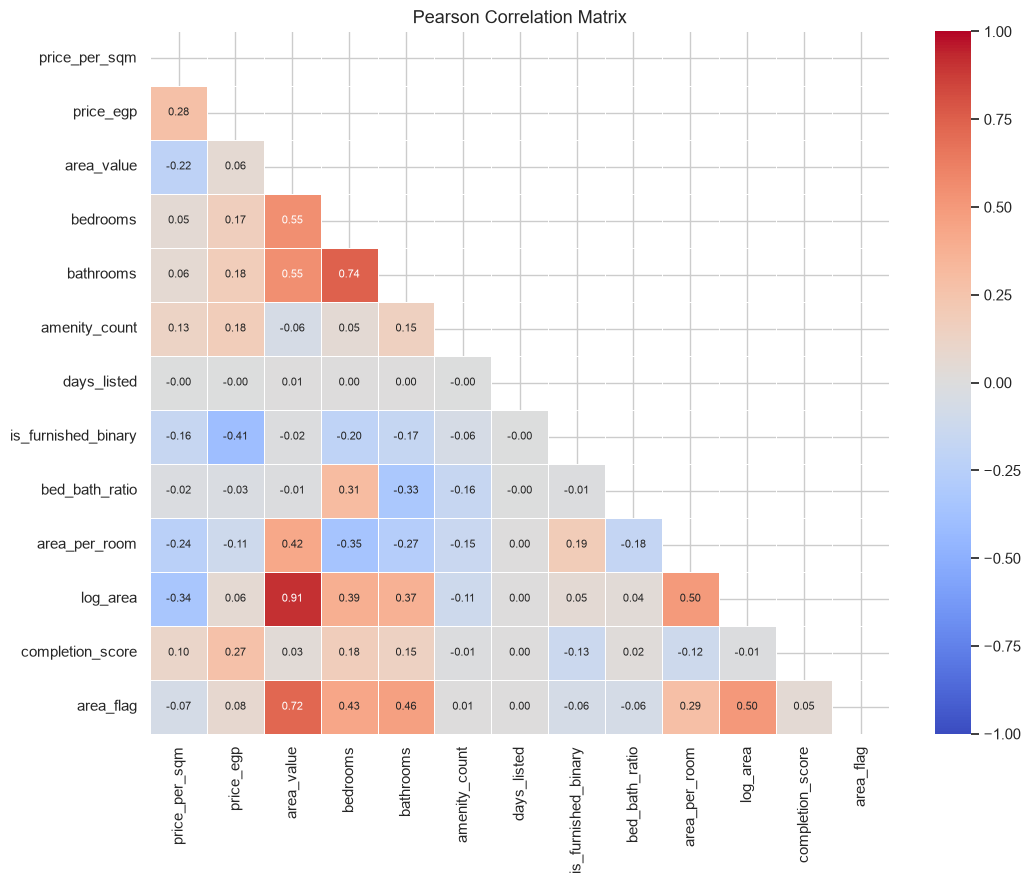

In [7]:
# Pearson correlation heatmap
# Values close to +1 = strong positive link, close to -1 = strong negative link, 0 = no link
pearson = corr_df.corr(method='pearson')

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    pearson,
    mask=np.triu(np.ones_like(pearson, dtype=bool)),  # hide the upper triangle (it's a mirror)
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

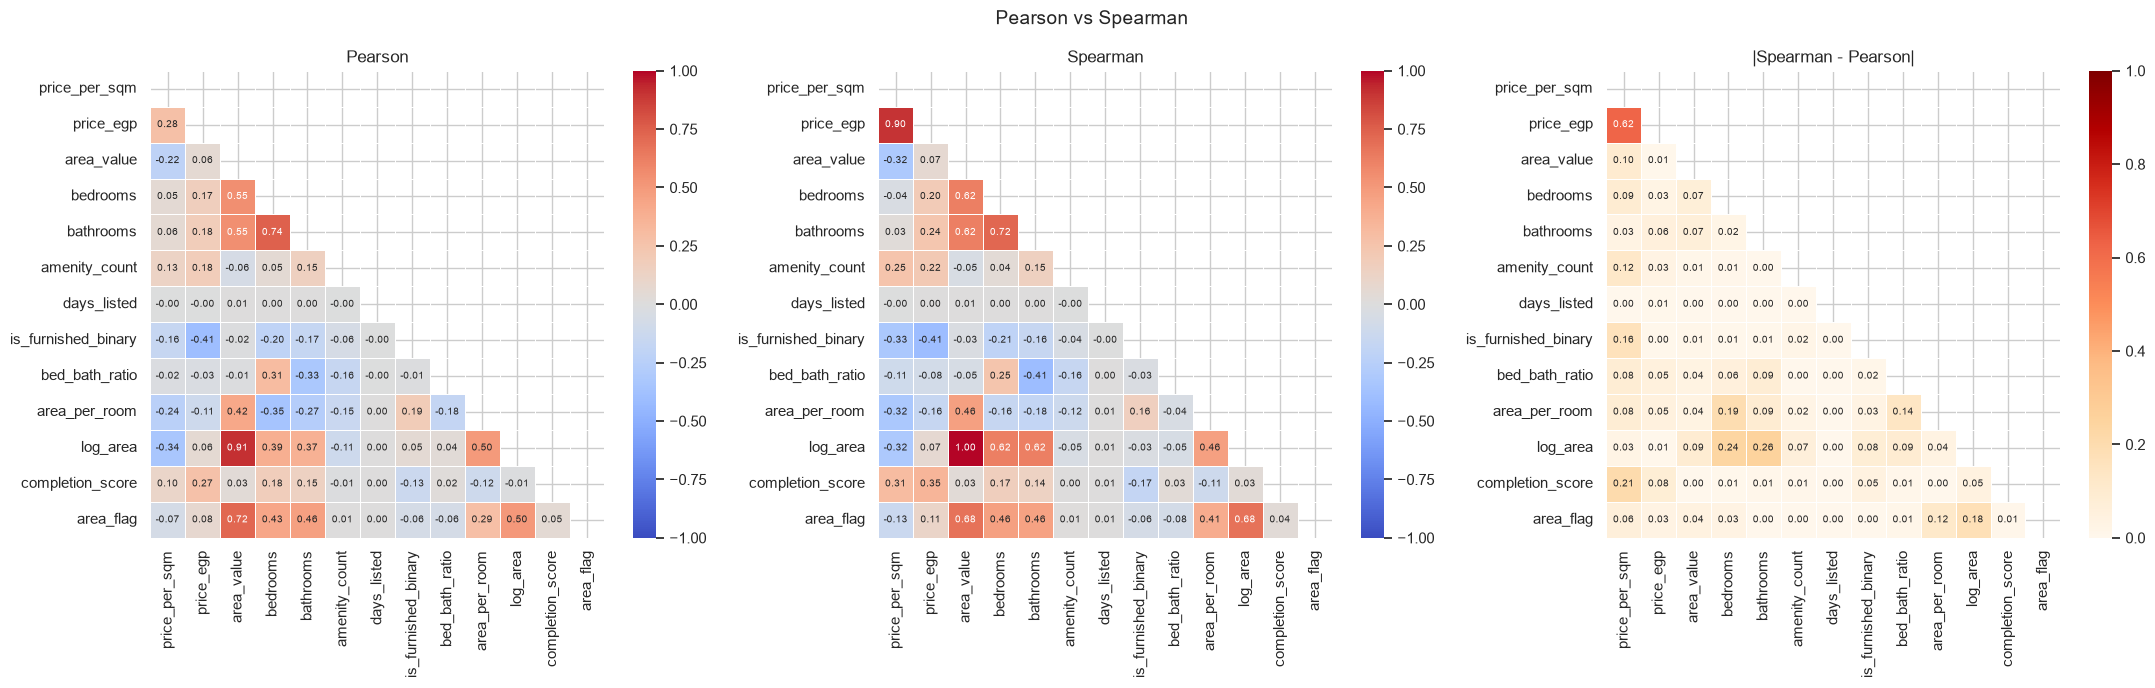

Top 5 pairs where the two methods disagree most:


,A,B,delta
13,price_egp,price_per_sqm,0.623214
134,log_area,bathrooms,0.257126
133,log_area,bedrooms,0.238468
143,completion_score,price_per_sqm,0.205986
120,area_per_room,bedrooms,0.194619


In [8]:
# Compare Pearson and Spearman correlations
# Where they disagree a lot, the relationship is non-linear
spearman = corr_df.corr(method='spearman')
diff = (spearman - pearson).abs()   # absolute difference between the two

fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, mat, title, cmap, vmin in zip(
    axes,
    [pearson, spearman, diff],
    ['Pearson', 'Spearman', '|Spearman - Pearson|'],
    ['coolwarm', 'coolwarm', 'OrRd'],
    [-1, -1, 0]
):
    sns.heatmap(
        mat,
        mask=np.triu(np.ones_like(mat, dtype=bool)),
        annot=True, fmt='.2f', cmap=cmap,
        center=0 if vmin < 0 else None, vmin=vmin, vmax=1,
        linewidths=0.4, ax=ax, annot_kws={'size': 7}
    )
    ax.set_title(title, fontsize=12)

plt.suptitle('Pearson vs Spearman', fontsize=14)
plt.tight_layout()
plt.show()

# Show the top 5 pairs where Pearson and Spearman disagree most
upper = diff.where(np.tril(np.ones(diff.shape), -1).astype(bool))
top5 = (
    upper.stack().reset_index()
    .rename(columns={'level_0': 'A', 'level_1': 'B', 0: 'delta'})
    .sort_values('delta', ascending=False).head(5)
)
print('Top 5 pairs where the two methods disagree most:')
display(top5)

Binary columns found: 32


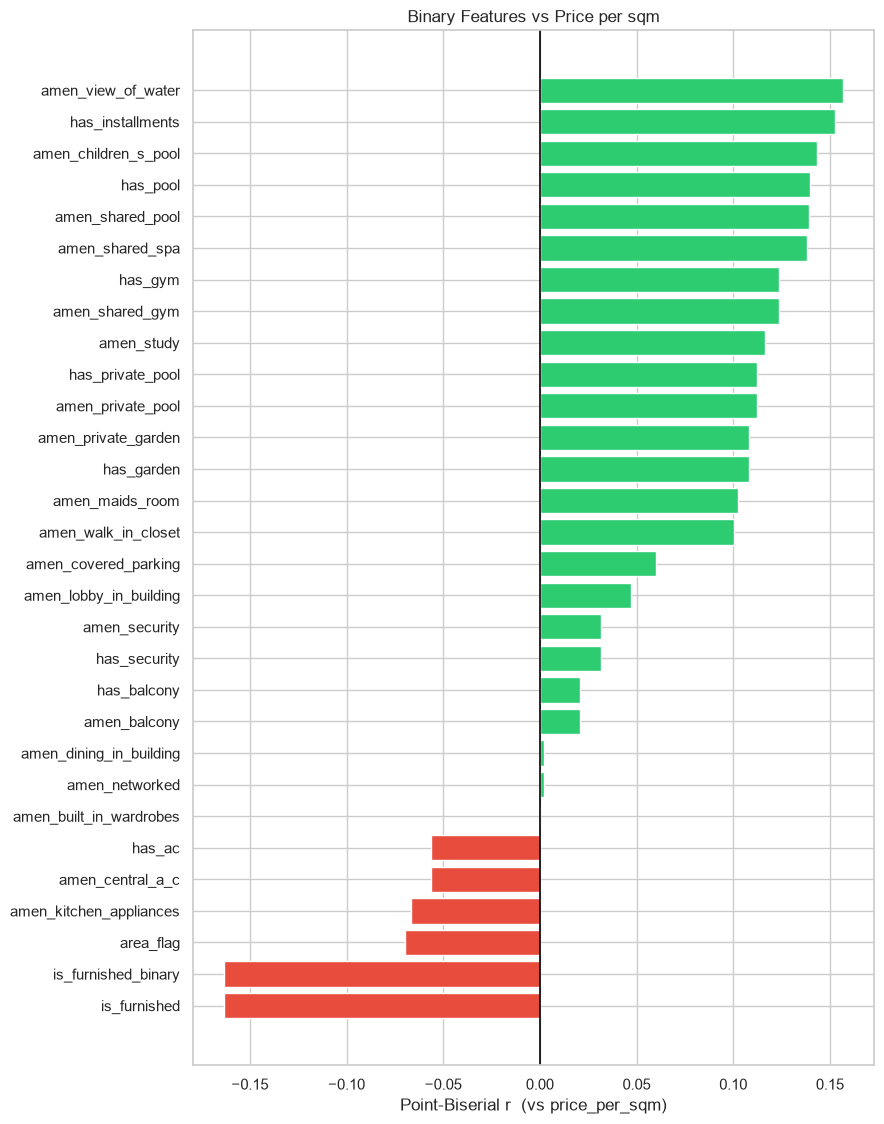

In [9]:
# Point-biserial correlation: how much do yes/no features relate to price per sqm?
# A positive r means having that feature is linked to higher price
# A negative r means having it is linked to lower price

# Find all binary (0/1) columns
binary_cols = [
    c for c in df_clean.columns
    if df_clean[c].dropna().isin([0, 1]).all()
    and df_clean[c].nunique() == 2
    and df_clean[c].dtype in ['int64', 'float64']
    and c not in ['is_outlier', 'label']
    and 'price' not in c
]
print(f'Binary columns found: {len(binary_cols)}')

pb_rows = []
price_s = df_clean['price_per_sqm'].dropna()

for col in binary_cols:
    tmp = pd.concat([price_s, df_clean[col]], axis=1).dropna()
    if tmp[col].nunique() < 2:
        continue
    r, p = pointbiserialr(tmp[col], tmp['price_per_sqm'])
    pb_rows.append({'feature': col, 'r_pb': round(r, 4), 'p_value': round(p, 4)})

pb_df   = pd.DataFrame(pb_rows).sort_values('r_pb', ascending=False).reset_index(drop=True)
plot_pb = pd.concat([pb_df.head(15), pb_df.tail(15)]).drop_duplicates('feature').sort_values('r_pb')

# Green bars = positively linked to price, red bars = negatively linked
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in plot_pb['r_pb']]

fig, ax = plt.subplots(figsize=(9, max(5, len(plot_pb) * 0.38)))
ax.barh(plot_pb['feature'], plot_pb['r_pb'], color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=1.2)
ax.set_xlabel('Point-Biserial r  (vs price_per_sqm)')
ax.set_title('Binary Features vs Price per sqm')
plt.tight_layout()
plt.show()

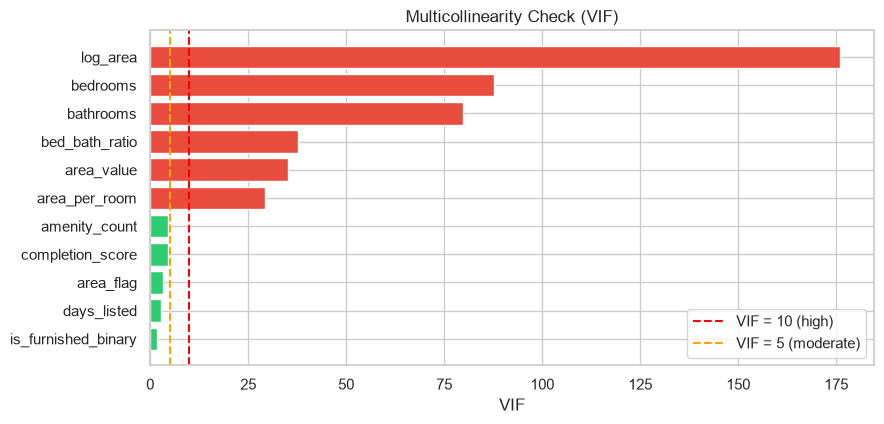

,feature,VIF,note
8,log_area,175.85,HIGH — consider dropping
1,bedrooms,87.75,HIGH — consider dropping
2,bathrooms,79.70,HIGH — consider dropping
6,bed_bath_ratio,37.78,HIGH — consider dropping
0,area_value,35.10,HIGH — consider dropping
7,area_per_room,29.30,HIGH — consider dropping
3,amenity_count,4.47,ok
9,completion_score,4.43,ok
10,area_flag,3.21,ok
4,days_listed,2.67,ok


In [10]:
# VIF (Variance Inflation Factor) checks for multicollinearity
# If two features are highly correlated with each other, one of them might be redundant
# Rule of thumb: VIF > 10 means high redundancy, VIF > 5 is worth watching

vif_cols = [c for c in CORR_COLS if c not in ('price_per_sqm', 'price_egp') and c in df_clean.columns]
vif_data = df_clean[vif_cols].dropna()

vif_rows = []
for i, col in enumerate(vif_cols):
    try:
        v = variance_inflation_factor(vif_data.values, i)
        vif_rows.append({'feature': col, 'VIF': round(v, 2)})
    except Exception:
        vif_rows.append({'feature': col, 'VIF': np.nan})

vif_df = pd.DataFrame(vif_rows).sort_values('VIF', ascending=False)
vif_df['note'] = vif_df['VIF'].apply(
    lambda v: 'HIGH — consider dropping' if v > 10 else ('moderate' if v > 5 else 'ok')
)

# Color: red = problem, orange = watch out, green = fine
colors_v = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71' for v in vif_df['VIF'].fillna(0)]
fig, ax = plt.subplots(figsize=(9, max(4, len(vif_df) * 0.4)))
ax.barh(vif_df['feature'][::-1], vif_df['VIF'][::-1], color=colors_v[::-1])
ax.axvline(10, color='red',    lw=1.5, ls='--', label='VIF = 10 (high)')
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='VIF = 5 (moderate)')
ax.set_xlabel('VIF')
ax.set_title('Multicollinearity Check (VIF)')
ax.legend()
plt.tight_layout()
plt.show()
display(vif_df)

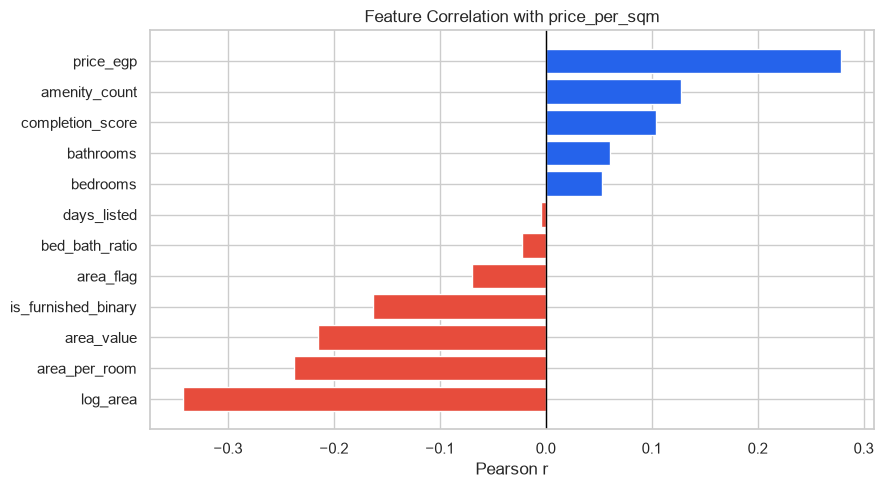

log_area              -0.342
area_per_room         -0.237
area_value            -0.215
is_furnished_binary   -0.163
area_flag             -0.070
bed_bath_ratio        -0.022
days_listed           -0.004
bedrooms               0.053
bathrooms              0.061
completion_score       0.104
amenity_count          0.128
price_egp              0.279


In [11]:
# Summary: how does each feature correlate with the target (price per sqm)?
# Blue = positive link, red = negative link
feat_corr = corr_df.corr()['price_per_sqm'].drop('price_per_sqm').sort_values()
colors_fc = ['#e74c3c' if v < 0 else '#2563EB' for v in feat_corr]

fig, ax = plt.subplots(figsize=(9, max(4, len(feat_corr) * 0.42)))
ax.barh(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_xlabel('Pearson r')
ax.set_title('Feature Correlation with price_per_sqm')
plt.tight_layout()
plt.show()

print(feat_corr.round(3).to_string())

## Step 5 — Target Encoder

Columns like `city` and `property_type` contain text categories. Models need numbers, not text.

We use **target encoding**: replace each category with the average price of listings in that category.

We add **Bayesian smoothing** to handle rare categories. If a city has very few listings, we mix its average with the global average so it does not dominate the model.

This encoder runs inside a pipeline, so it is only fitted on training data — no data leakage.

In [12]:
class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Replaces each text category with a smoothed average of the target.
    Rare categories are pulled toward the global mean to avoid overfitting.
    """

    def __init__(self, cols, smoothing=30):
        self.cols      = cols       # which columns to encode
        self.smoothing = smoothing  # higher = more smoothing for rare categories

    def fit(self, X, y):
        y = pd.Series(y).reset_index(drop=True)
        X = X.reset_index(drop=True)

        self.global_mean_ = float(y.mean())   # overall average
        self.maps_ = {}

        for col in self.cols:
            if col not in X.columns:
                continue
            frame = pd.DataFrame({'cat': X[col].values, 'tgt': y.values})
            stats = frame.groupby('cat')['tgt'].agg(['mean', 'count'])
            n, m, s = stats['count'], stats['mean'], self.smoothing
            # Smoothed mean formula: (n * category_mean + s * global_mean) / (n + s)
            self.maps_[col] = ((n * m + s * self.global_mean_) / (n + s)).to_dict()

        return self

    def transform(self, X):
        X = X.copy()
        for col, mapping in self.maps_.items():
            if col in X.columns:
                # Replace the text column with its numeric encoding
                X[f'{col}_enc'] = X[col].map(mapping).fillna(self.global_mean_)
                X = X.drop(columns=[col])
        return X


print('TargetEncoder is ready to use.')

TargetEncoder is ready to use.


## Step 6 — Choose Features

Based on the correlation analysis we just ran, here are the key findings:

- `area_flag` is the strongest binary predictor (r = 0.49) — large properties cost more per sqm
- `is_furnished_binary` is negative (r = -0.18) — furnished listings tend to be smaller and cheaper per sqm
- `images_count` was removed — almost zero correlation, adds noise
- Luxury amenities (pool, gym, garden) all point to higher price per sqm

In [13]:
# Text columns that will be target-encoded
CAT_COLS = [c for c in ['city', 'town', 'district', 'property_type'] if c in df_clean.columns]

# Numeric features selected from the correlation analysis
NUM_FEATURES = [
    # Size and layout — strongest numeric predictors
    'area_value', 'log_area',
    'bedrooms', 'bathrooms',
    'bed_bath_ratio', 'total_rooms', 'area_per_room', 'area_x_beds',
    'area_flag',            # 1 if property is in the top 25% by area

    # Amenity quality
    'amenity_count',
    'is_furnished_binary',  # r = -0.18 with price per sqm
    'has_installments',     # r = +0.15 (high-value off-plan properties)

    # Luxury amenity flags (all positively linked to price)
    'has_pool', 'has_private_pool',
    'has_gym',
    'has_garden',
    'has_parking',
    'has_security',
    'has_balcony',
    'has_ac',

    # Listing metadata
    'completion_score',
    'days_listed',
]

# Add geographic coordinates if available
if 'lat' in df_clean.columns:
    NUM_FEATURES += ['lat', 'lon']

# Add quality flags if available
for flag in ['is_premium', 'is_verified', 'is_new_construction', 'is_direct_from_dev', 'is_featured']:
    if flag in df_clean.columns:
        NUM_FEATURES.append(flag)

# Keep only columns that actually exist in the dataset
NUM_FEATURES = [c for c in NUM_FEATURES if c in df_clean.columns]

print(f'Numeric features : {len(NUM_FEATURES)}')
print(f'Category columns : {CAT_COLS}')
print(f'Feature list     : {NUM_FEATURES}')

Numeric features : 29
Category columns : ['city', 'town', 'district', 'property_type']
Feature list     : ['area_value', 'log_area', 'bedrooms', 'bathrooms', 'bed_bath_ratio', 'total_rooms', 'area_per_room', 'area_x_beds', 'area_flag', 'amenity_count', 'is_furnished_binary', 'has_installments', 'has_pool', 'has_private_pool', 'has_gym', 'has_garden', 'has_parking', 'has_security', 'has_balcony', 'has_ac', 'completion_score', 'days_listed', 'lat', 'lon', 'is_premium', 'is_verified', 'is_new_construction', 'is_direct_from_dev', 'is_featured']


## Step 7 — Split into Train and Test Sets

We train only on **Buy listings**. Buy and Rent prices are on completely different scales, so mixing them would give a misleadingly high score.

We also apply a tighter price and area filter to remove edge cases:
- `price_per_sqm`: between the 1st and 99th percentile
- `area_value`: between 20 and 2,000 sqm

The target we predict is `log(price_per_sqm + 1)`. Taking the log reduces the effect of very high prices and makes the distribution more symmetric. We reverse it at evaluation time using `exp(prediction) - 1`.

Split: 80% train, 20% test.

In [14]:
df_reg = df_clean.copy()

# Keep only Buy listings (not Rent)
offer_col = 'offering_type' if 'offering_type' in df_reg.columns else (
             'category'      if 'category'      in df_reg.columns else None)
if offer_col:
    df_reg = df_reg[df_reg[offer_col].str.lower() == 'buy'].copy()
    print(f'Buy listings: {len(df_reg):,}')
else:
    print('No offering_type column found — using all rows')

# Calculate price per square meter
if 'price_per_sqm' not in df_reg.columns:
    df_reg['price_per_sqm'] = df_reg['price_egp'] / df_reg['area_value'].replace(0, np.nan)

# Remove duplicate listings
if 'listing_id' in df_reg.columns:
    before = len(df_reg)
    df_reg = df_reg.drop_duplicates(subset=['listing_id'], keep='first')
    print(f'After removing duplicates: {len(df_reg):,}  (removed {before - len(df_reg):,})')

# Apply the price and area filters
lo_price, hi_price = df_reg['price_per_sqm'].quantile([0.01, 0.99])
lo_area,  hi_area  = 20, 2000

before = len(df_reg)
df_reg = df_reg[
    (df_reg['price_per_sqm'] >= lo_price) & (df_reg['price_per_sqm'] <= hi_price)
    & (df_reg['area_value']   >= lo_area)  & (df_reg['area_value']   <= hi_area)
    & df_reg['price_per_sqm'].notna()
]
print(f'After price/area filter: {len(df_reg):,}  (removed {before - len(df_reg):,} rows)')
print(f'Price/sqm range: {df_reg["price_per_sqm"].min():,.0f} to {df_reg["price_per_sqm"].max():,.0f} EGP')

# Build the feature matrix
keep = [c for c in NUM_FEATURES + CAT_COLS + ['price_per_sqm'] if c in df_reg.columns]
df_reg = df_reg[keep].copy()

# Fill missing numeric values with the median of each column
for col in NUM_FEATURES:
    if col in df_reg.columns:
        df_reg[col] = df_reg[col].fillna(df_reg[col].median())

X = df_reg.drop(columns=['price_per_sqm'])
y = np.log1p(df_reg['price_per_sqm'])   # log transform the target

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)
cat_in_train = [c for c in CAT_COLS if c in X_train.columns]

print(f'\nTrain: {len(X_train):,}   Test: {len(X_test):,}   Features: {X.shape[1]}')
print(f'Categorical columns in pipeline: {cat_in_train}')

Buy listings: 15,768
After removing duplicates: 15,768  (removed 0)
After price/area filter: 15,418  (removed 350 rows)
Price/sqm range: 14,368 to 337,500 EGP

Train: 12,334   Test: 3,084   Features: 33
Categorical columns in pipeline: ['city', 'town', 'district', 'property_type']


## Step 8 — Train the Models

We train four models and wrap each one in a pipeline that includes the target encoder.

We also run **5-fold cross-validation** on each model. This splits the training data into 5 parts, trains on 4 and tests on 1, and repeats 5 times. The average score is more reliable than a single train/test split.

In [15]:
# Helper function: builds a pipeline with encoder -> (optional scaler) -> model
def make_pipeline(model, scale=False):
    steps = [('enc', TargetEncoder(cols=cat_in_train, smoothing=20))]
    if scale:
        steps.append(('scaler', StandardScaler()))   # Ridge needs features on the same scale
    steps.append(('model', model))
    return Pipeline(steps)


models = {
    # Ridge: simple linear model with regularization to prevent overfitting
    'Ridge': make_pipeline(
        Ridge(alpha=10), scale=True
    ),

    # Random Forest: an ensemble of decision trees, each trained on a random subset
    'RandomForest': make_pipeline(
        RandomForestRegressor(
            n_estimators=200,   # number of trees
            max_depth=12,       # max depth per tree (limits complexity)
            n_jobs=-1,
            random_state=SEED
        )
    ),

    # XGBoost: builds trees one at a time, each correcting the previous one
    'XGBoost': make_pipeline(
        XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,   # smaller = slower but more accurate
            max_depth=7,
            subsample=0.8,        # use 80% of rows per tree
            colsample_bytree=0.8, # use 80% of features per tree
            n_jobs=-1,
            random_state=SEED,
            verbosity=0
        )
    ),

    # LightGBM: similar to XGBoost but faster, especially on large datasets
    'LightGBM': make_pipeline(
        lgb.LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            num_leaves=63,
            feature_fraction=0.8,
            bagging_fraction=0.8,
            bagging_freq=5,
            n_jobs=-1,
            random_state=SEED,
            verbose=-1
        )
    ),
}

# 5-fold cross-validation setup
cv      = KFold(n_splits=5, shuffle=True, random_state=SEED)
results = {}

for name, pipe in models.items():
    # Cross-validation on the training set
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='r2', n_jobs=-1)

    # Train on the full training set
    pipe.fit(X_train, y_train)

    # Predict on the test set and reverse the log transform
    y_pred_log  = pipe.predict(X_test)
    y_pred_real = np.expm1(y_pred_log)   # undo the log: exp(pred) - 1
    y_test_real = np.expm1(y_test)

    # Calculate metrics
    r2       = r2_score(y_test, y_pred_log)
    rmse     = np.sqrt(mean_squared_error(y_test_real, y_pred_real))
    mae      = mean_absolute_error(y_test_real, y_pred_real)
    r2_train = r2_score(y_train, pipe.predict(X_train))
    gap      = round(r2_train - r2, 4)   # overfit gap: if large, model memorized training data

    results[name] = {
        'cv_r2_mean':  round(cv_scores.mean(), 4),
        'cv_r2_std':   round(cv_scores.std(),  4),
        'train_r2':    round(r2_train, 4),
        'test_r2':     round(r2, 4),
        'overfit_gap': gap,
        'rmse_egp':    round(rmse, 0),
        'mae_egp':     round(mae, 0),
        'pipe':        pipe,
        'y_pred_real': y_pred_real,
    }

    print(
        f'{name:<15}  CV R²={cv_scores.mean():.4f} ± {cv_scores.std():.4f}  '
        f'Train={r2_train:.4f}  Test={r2:.4f}'
    )

Ridge            CV R²=0.4754 ± 0.0121  Train=0.4890  Test=0.4643
RandomForest     CV R²=0.7020 ± 0.0155  Train=0.8639  Test=0.7278
XGBoost          CV R²=0.7449 ± 0.0115  Train=0.9363  Test=0.7593
LightGBM         CV R²=0.7386 ± 0.0109  Train=0.9199  Test=0.7564


## Step 9 — Compare Models

The table below shows the key metrics for each model.

- **CV R²** is the most honest score — the model never saw this data during training
- **RMSE** is the typical error in EGP per sqm — easier to understand than R²
- A large gap between Train R² and Test R² means the model overfit (memorized the training data)

In [16]:
# Build a summary table of all model metrics
summary = pd.DataFrame({
    k: {
        'CV R² (mean)':   v['cv_r2_mean'],
        'CV R² (std)':    v['cv_r2_std'],
        'Train R²':       v['train_r2'],
        'Test R²':        v['test_r2'],
        'RMSE (EGP/sqm)': f"{v['rmse_egp']:,.0f}",
        'MAE (EGP/sqm)':  f"{v['mae_egp']:,.0f}",
    }
    for k, v in results.items() if k != 'pipe'
}).T

display(summary)

,CV R² (mean),CV R² (std),Train R²,Test R²,RMSE (EGP/sqm),MAE (EGP/sqm)
Ridge,0.4754,0.0121,0.489,0.4643,"33,114","21,364"
RandomForest,0.702,0.0155,0.8639,0.7278,"24,899","14,580"
XGBoost,0.7449,0.0115,0.9363,0.7593,"23,947","13,711"
LightGBM,0.7386,0.0109,0.9199,0.7564,"24,260","13,950"


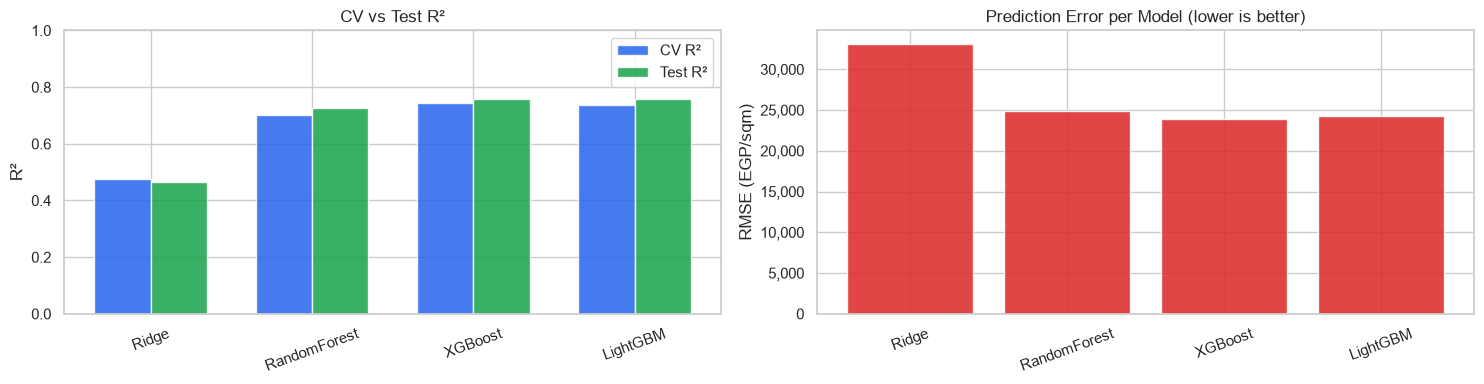

In [17]:
# Bar charts: CV R² vs Test R² and RMSE per model
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
names     = list(results.keys())
test_r2   = [results[k]['test_r2']    for k in names]
cv_r2     = [results[k]['cv_r2_mean'] for k in names]
rmse_vals = [results[k]['rmse_egp']   for k in names]

x = np.arange(len(names))
w = 0.35

# Left chart: CV R² vs Test R² side by side
axes[0].bar(x - w/2, cv_r2,   w, label='CV R²',  color='#2563EB', alpha=0.85)
axes[0].bar(x + w/2, test_r2, w, label='Test R²', color='#16A34A', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(names, rotation=20)
axes[0].set_ylabel('R²')
axes[0].set_title('CV vs Test R²')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Right chart: RMSE per model (lower is better)
axes[1].bar(names, rmse_vals, color='#DC2626', alpha=0.85)
axes[1].set_ylabel('RMSE (EGP/sqm)')
axes[1].set_title('Prediction Error per Model (lower is better)')
plt.setp(axes[1].get_xticklabels(), rotation=20)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:,.0f}'))

plt.tight_layout()
plt.show()

## Step 10 — Predicted vs Actual Price

Each chart below plots what the model predicted against the real price.

The dashed red line represents perfect prediction (predicted = actual). The closer the dots are to this line, the better the model is performing.

A cloud that fans out at higher prices (funnel shape) is common in real estate — prices are harder to predict at the luxury end.

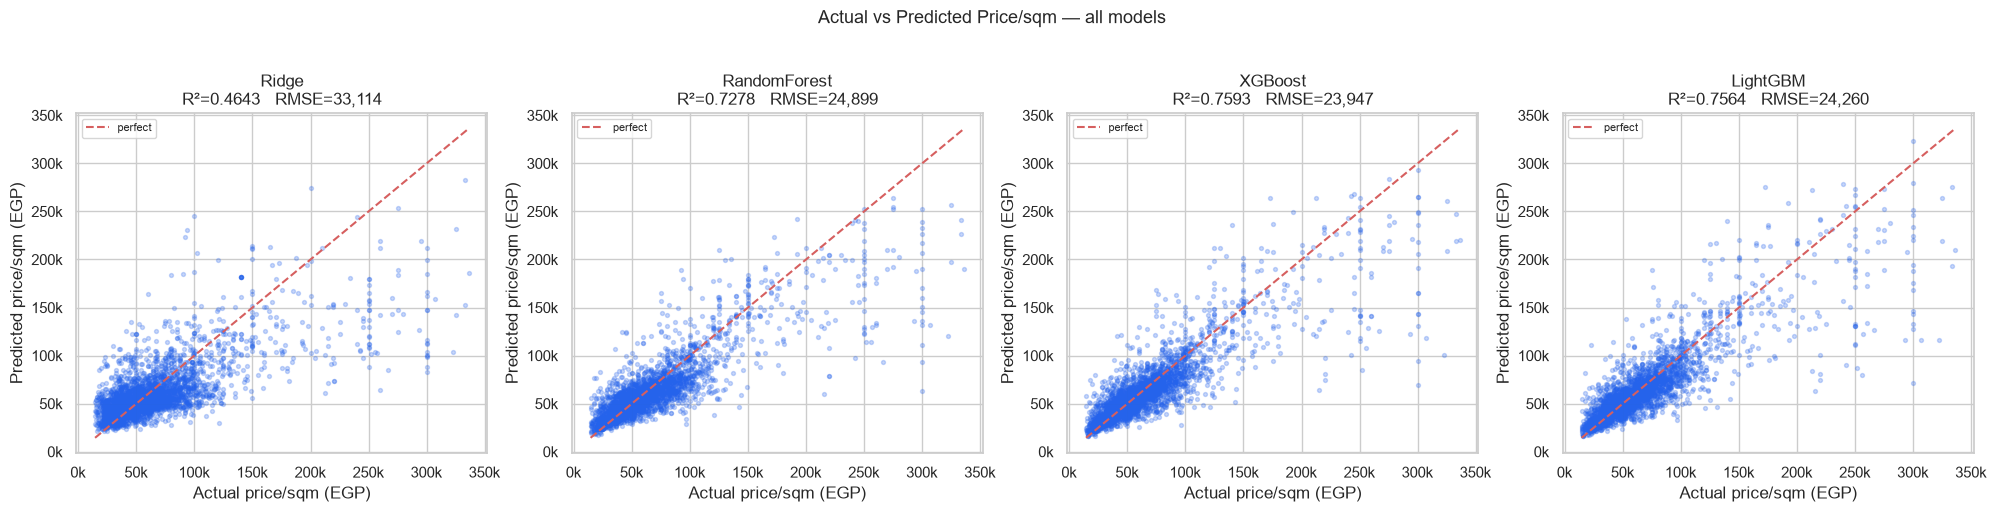

In [18]:
y_test_real = np.expm1(y_test)   # convert back from log scale

fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))

for ax, (name, res) in zip(axes, results.items()):
    y_pred = res['y_pred_real']

    # Scatter: each dot is one listing
    ax.scatter(y_test_real, y_pred, alpha=0.25, s=8, color='#2563EB')

    # Perfect prediction line
    lims = [
        min(y_test_real.min(), y_pred.min()),
        max(y_test_real.max(), y_pred.max())
    ]
    ax.plot(lims, lims, 'r--', lw=1.5, label='perfect')

    ax.set_xlabel('Actual price/sqm (EGP)')
    ax.set_ylabel('Predicted price/sqm (EGP)')
    ax.set_title(f'{name}\nR²={res["test_r2"]:.4f}   RMSE={res["rmse_egp"]:,.0f}')
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))
    ax.legend(fontsize=8)

plt.suptitle('Actual vs Predicted Price/sqm — all models', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [19]:
# Show a sample of 30 predictions from the best-performing model
best_name = max(results, key=lambda k: results[k]['test_r2'])
best_pred_val = results[best_name]['y_pred_real']

sample_df = pd.DataFrame({
    'actual_price_per_sqm':   np.round(y_test_real.values, 0),
    f'{best_name}_predicted': np.round(best_pred_val, 0),
    'error_egp':              np.round(best_pred_val - y_test_real.values, 0),
    'error_pct':              np.round((best_pred_val - y_test_real.values) / y_test_real.values * 100, 1),
}).reset_index(drop=True)

print(f'Best model: {best_name}  (Test R² = {results[best_name]["test_r2"]})')
print(f'Sample of 30 test predictions:\n')
display(sample_df.head(30))

print()
# How many predictions are within 10%, 20%, 30% of the real price?
for pct in [10, 20, 30]:
    within = (sample_df['error_pct'].abs() <= pct).mean() * 100
    print(f'Predictions within {pct}% of actual: {within:.1f}%')

Best model: XGBoost  (Test R² = 0.7593)
Sample of 30 test predictions:



,actual_price_per_sqm,XGBoost_predicted,error_egp,error_pct
0,92818.0,43449.0,-49369.0,-53.2
1,91758.0,83352.0,-8406.0,-9.2
2,47000.0,42571.0,-4429.0,-9.4
3,35333.0,31036.0,-4297.0,-12.2
4,29429.0,31910.0,2481.0,8.4
5,59048.0,45004.0,-14044.0,-23.8
6,24845.0,27880.0,3035.0,12.2
7,41765.0,49350.0,7585.0,18.2
8,71429.0,57421.0,-14007.0,-19.6
9,22414.0,50354.0,27940.0,124.7



Predictions within 10% of actual: 37.9%
Predictions within 20% of actual: 63.4%
Predictions within 30% of actual: 78.9%


## Step 11 — Feature Importance

Tree-based models (Random Forest, XGBoost, LightGBM) can tell us which features they relied on most.

The chart below shows the top 20 features for the winning model. The top 5 are highlighted in blue.

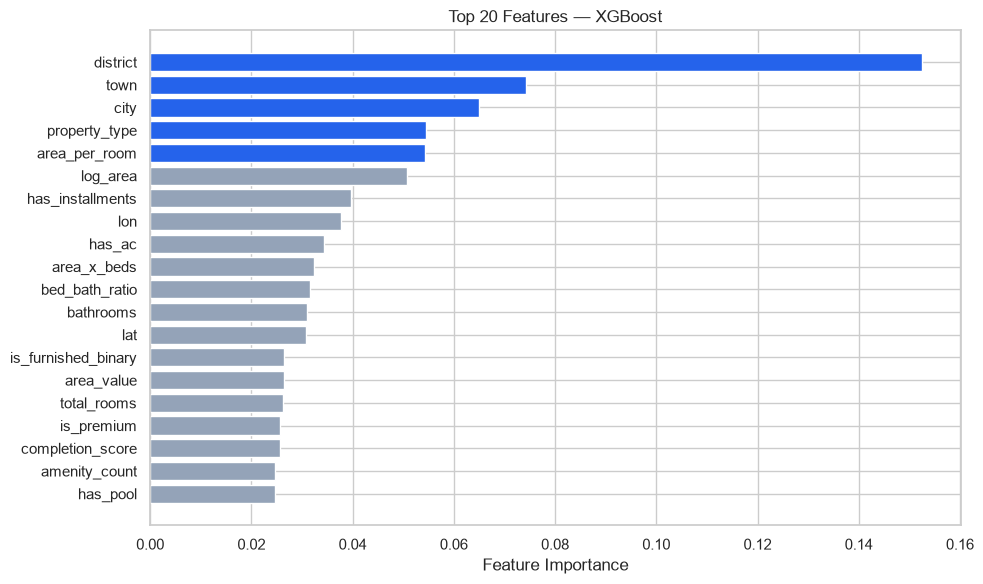

Top 15 features (XGBoost):
district               0.1525
town                   0.0742
city                   0.0650
property_type          0.0546
area_per_room          0.0542
log_area               0.0507
has_installments       0.0398
lon                    0.0376
has_ac                 0.0343
area_x_beds            0.0325
bed_bath_ratio         0.0315
bathrooms              0.0309
lat                    0.0307
is_furnished_binary    0.0265
area_value             0.0264


In [20]:
best_pipe = results[best_name]['pipe']

if hasattr(best_pipe.named_steps['model'], 'feature_importances_'):
    m = best_pipe.named_steps['model']

    # Get feature names from the training data columns (not from the model internals)
    feat_names = list(X_train.columns)
    imp = pd.Series(m.feature_importances_, index=feat_names).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 6))
    top = imp.head(20)

    # Top 5 in blue, the rest in grey
    colors_i = ['#2563EB' if i < 5 else '#94A3B8' for i in range(len(top))]
    ax.barh(top.index[::-1], top.values[::-1], color=colors_i[::-1])
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Top 20 Features — {best_name}')
    plt.tight_layout()
    plt.show()

    print(f'Top 15 features ({best_name}):')
    print(imp.head(15).round(4).to_string())
else:
    print(f'{best_name} does not expose feature importances (Ridge regression does not have them).')

## Step 12 — Residual Analysis

A residual is the difference between the actual price and the predicted price.

A well-behaved model has residuals that are:
- Centered around zero (no consistent over- or under-prediction)
- Spread evenly at all predicted values (no funnel shape)
- Roughly bell-shaped

If you see a funnel shape in the first chart, the model predicts cheap listings well but struggles with expensive ones.

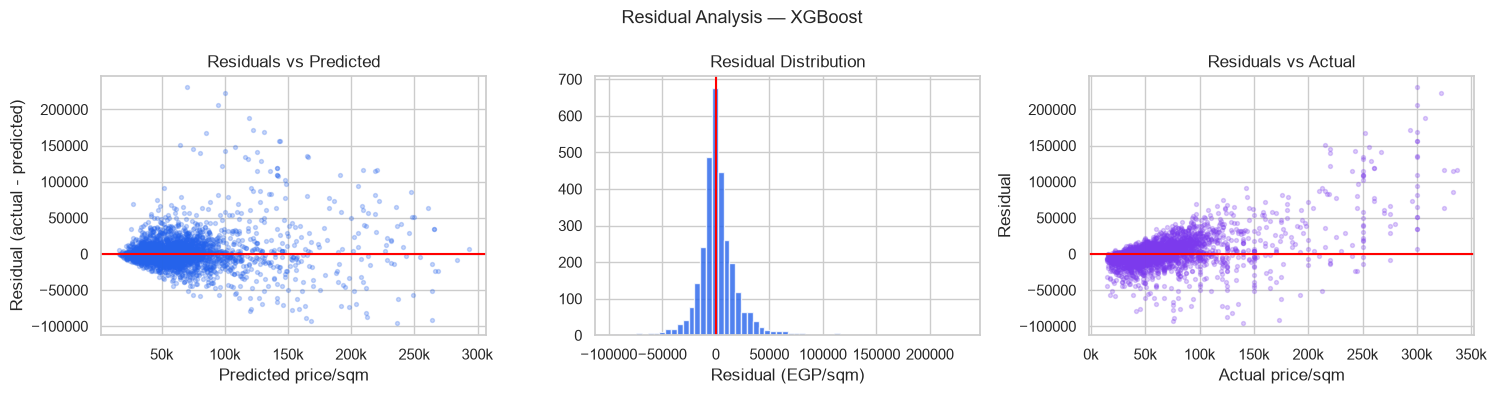

Mean residual    : 2,701 EGP/sqm  (closer to 0 = less bias)
Std of residuals : 23,794 EGP/sqm
Median abs error : 7,627 EGP/sqm


In [21]:
best_pred_res = results[best_name]['y_pred_real']
residuals = y_test_real.values - best_pred_res   # actual minus predicted

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Chart 1: residuals vs predicted — checking for funnel shape
axes[0].scatter(best_pred_res, residuals, alpha=0.25, s=8, color='#2563EB')
axes[0].axhline(0, color='red', lw=1.5)   # zero line
axes[0].set_xlabel('Predicted price/sqm')
axes[0].set_ylabel('Residual (actual - predicted)')
axes[0].set_title('Residuals vs Predicted')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))

# Chart 2: distribution of residuals — should look like a bell curve
axes[1].hist(residuals, bins=60, color='#2563EB', edgecolor='white', alpha=0.8)
axes[1].axvline(0, color='red', lw=1.5)
axes[1].set_xlabel('Residual (EGP/sqm)')
axes[1].set_title('Residual Distribution')

# Chart 3: residuals vs actual price
axes[2].scatter(y_test_real.values, residuals, alpha=0.25, s=8, color='#7C3AED')
axes[2].axhline(0, color='red', lw=1.5)
axes[2].set_xlabel('Actual price/sqm')
axes[2].set_ylabel('Residual')
axes[2].set_title('Residuals vs Actual')
axes[2].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v / 1000:.0f}k'))

plt.suptitle(f'Residual Analysis — {best_name}', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mean residual    : {residuals.mean():,.0f} EGP/sqm  (closer to 0 = less bias)')
print(f'Std of residuals : {residuals.std():,.0f} EGP/sqm')
print(f'Median abs error : {np.median(np.abs(residuals)):,.0f} EGP/sqm')

## Step 13 — Classify Buy vs Rent

Now we switch from regression to classification. Instead of predicting a price, we predict whether a listing is for **Buy** or **Rent**.

- **Target:** Buy = 1, Rent = 0
- **Models:** Logistic Regression, Random Forest, XGBoost
- **Main metric:** ROC-AUC (works well even when classes are imbalanced)

We remove features that would leak the answer (e.g., `has_installments` only exists for Buy listings).

In [22]:
# Start from the full clean dataset (Buy + Rent)
df_ml = df_clean.copy()

# Fill numeric nulls with median
for col in NUM_FEATURES:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].fillna(df_ml[col].median())

# Remove rows where offering_type is unknown
df_ml = df_ml.dropna(subset=['offering_type'])
print(f'Dataset shape: {df_ml.shape}')

# These features are only meaningful for Buy listings — including them would
# let the model cheat by looking at the answer indirectly
LEAKY_FOR_CLF = {'has_installments', 'is_new_construction',
                  'is_direct_from_dev', 'completion_score'}

CLF_NUM_FEATURES = [f for f in NUM_FEATURES if f not in LEAKY_FOR_CLF]
print(f'Removed leaky features : {[f for f in NUM_FEATURES if f in LEAKY_FOR_CLF]}')
print(f'Remaining features     : {len(CLF_NUM_FEATURES)}')

# Create the binary target column: Buy = 1, Rent = 0
df_ml['offering_type_bin'] = (df_ml['offering_type'] == 'Buy').astype(int)

feature_cols = [c for c in CLF_NUM_FEATURES + CAT_COLS if c in df_ml.columns]
X_raw = df_ml[feature_cols].copy()
y_clf = df_ml['offering_type_bin'].values

# Stratify to keep the same Buy/Rent ratio in train and test
def safe_stratify(series):
    return series if series.value_counts().min() >= 2 else None

stratify = safe_stratify(df_ml['offering_type_bin'])
if stratify is None:
    print('Stratification skipped — class imbalance too severe.')

X_tr_raw, X_te_raw, y_tr, y_te, idx_tr, idx_te = train_test_split(
    X_raw, y_clf, df_ml.index,
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=stratify
)

FEATURES = [c for c in CLF_NUM_FEATURES if c in X_raw.columns] + \
           [f'{c}_enc' for c in CAT_COLS if c in X_raw.columns]

# Redefine make_pipeline for classification (uses higher smoothing)
def make_pipeline(model, scale=False):
    steps = [('enc', TargetEncoder(cols=CAT_COLS, smoothing=100))]
    if scale:
        steps.append(('scale', StandardScaler()))
    steps.append(('model', model))
    return Pipeline(steps)

# Three classifiers to try
clf_models = {
    'LogisticRegression': make_pipeline(
        LogisticRegression(max_iter=1000, C=0.1, solver='liblinear', random_state=RANDOM_STATE),
        scale=True
    ),
    'RandomForest': make_pipeline(
        RandomForestClassifier(
            n_estimators=200, max_depth=4, min_samples_leaf=100, max_features=0.5,
            n_jobs=-1, random_state=RANDOM_STATE
        )
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=150, learning_rate=0.05, max_depth=2,
            min_child_weight=50, subsample=0.6, colsample_bytree=0.6,
            reg_lambda=10.0, reg_alpha=5.0, eval_metric='logloss',
            random_state=RANDOM_STATE, verbosity=0
        )
    ),
}

clf_metrics    = []
all_fi_records = []
best_clf_proba = None
best_clf_pred  = None
best_clf_auc   = -1
best_clf_name  = ''

for mname, model in clf_models.items():
    print(f'Training {mname}...')
    model.fit(X_tr_raw, y_tr)

    y_pred_c = model.predict(X_te_raw)
    y_proba  = (
        model.predict_proba(X_te_raw)[:, 1]
        if hasattr(model, 'predict_proba')
        else y_pred_c.astype(float)
    )

    train_proba = (
        model.predict_proba(X_tr_raw)[:, 1]
        if hasattr(model, 'predict_proba')
        else model.predict(X_tr_raw).astype(float)
    )

    train_auc = roc_auc_score(y_tr, train_proba)
    cv_auc    = cross_val_score(model, X_tr_raw, y_tr, cv=5, scoring='roc_auc', n_jobs=-1).mean()

    acc = accuracy_score(y_te, y_pred_c)
    f1  = f1_score(y_te, y_pred_c, average='weighted')
    auc = roc_auc_score(y_te, y_proba)
    gap = train_auc - auc   # overfit gap

    print(f'  CV AUC={cv_auc:.4f}  Train AUC={train_auc:.4f}  Test AUC={auc:.4f}  Gap={gap:.4f}')
    print(f'  Accuracy={acc:.4f}   F1={f1:.4f}')

    clf_metrics.append({'model': mname, 'Accuracy': acc, 'F1': f1, 'ROC_AUC': auc,
                        'CV_AUC': cv_auc, 'Train_AUC': train_auc, 'Gap': gap})

    # Collect feature importances if available
    if hasattr(model.named_steps['model'], 'feature_importances_'):
        feat_names = CLF_NUM_FEATURES + CAT_COLS
        for feat, imp in zip(feat_names, model.named_steps['model'].feature_importances_):
            all_fi_records.append({
                'segment': 'Classification', 'model': mname,
                'feature': feat, 'importance': imp
            })

    # Track the best classifier by cross-validation AUC
    if cv_auc > best_clf_auc:
        best_clf_auc   = cv_auc
        best_clf_proba = y_proba
        best_clf_pred  = y_pred_c
        best_clf_name  = mname

print(f'\nBest classifier: {best_clf_name}  (CV AUC = {best_clf_auc:.4f})')

Dataset shape: (33456, 87)
Removed leaky features : ['has_installments', 'completion_score', 'is_new_construction', 'is_direct_from_dev']
Remaining features     : 25
Training LogisticRegression...
  CV AUC=0.9357  Train AUC=0.9366  Test AUC=0.9356  Gap=0.0010
  Accuracy=0.8582   F1=0.8582
Training RandomForest...
  CV AUC=0.9295  Train AUC=0.9322  Test AUC=0.9300  Gap=0.0022
  Accuracy=0.8429   F1=0.8429
Training XGBoost...
  CV AUC=0.9428  Train AUC=0.9439  Test AUC=0.9419  Gap=0.0020
  Accuracy=0.8681   F1=0.8681

Best classifier: XGBoost  (CV AUC = 0.9428)


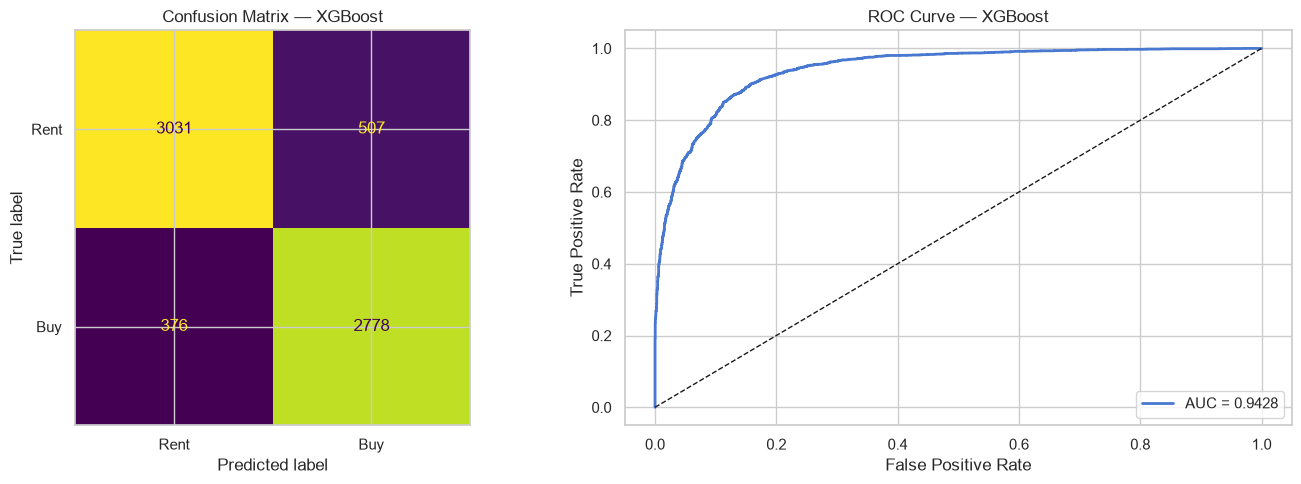

In [23]:
# Visualize the best classifier with a confusion matrix and ROC curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix: shows how many Buy/Rent listings were correctly classified
cm = confusion_matrix(y_te, best_clf_pred)
ConfusionMatrixDisplay(cm, display_labels=['Rent', 'Buy']).plot(ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_clf_name}', fontsize=12)

# ROC curve: shows the trade-off between catching true positives and false positives
# AUC = 1.0 is perfect, AUC = 0.5 is no better than random guessing
fpr, tpr, _ = roc_curve(y_te, best_clf_proba)
axes[1].plot(fpr, tpr, lw=2, label=f'AUC = {best_clf_auc:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)   # diagonal = random guessing
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title(f'ROC Curve — {best_clf_name}', fontsize=12)
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

In [24]:
# Collect regression metrics for the final summary table
regression_metrics = []
for _mname, _m in results.items():
    regression_metrics.append({
        'segment':   'Buy',
        'model':     _mname,
        'R2':        _m['test_r2'],
        'CV_R2':     _m['cv_r2_mean'],
        'CV_R2_std': _m['cv_r2_std'],
        'Train_R2':  _m['train_r2'],
        'Gap':       _m['overfit_gap'],
        'RMSE':      _m['rmse_egp'],
        'MAE':       _m['mae_egp'],
    })

_best_preds = results[best_name]['y_pred_real']
_test_meta  = df_clean.loc[X_test.index]

def _safe_col(df, col, fallback):
    return df[col].values if col in df.columns else fallback

# Build a predictions dataframe to export
_pred_frame = pd.DataFrame({
    'listing_id':      _safe_col(_test_meta, 'listing_id',    X_test.index),
    'offering_type':   'Buy',
    'city':            _safe_col(_test_meta, 'city',          np.nan),
    'property_type':   _safe_col(_test_meta, 'property_type', np.nan),
    'actual_price':    y_test_real.values,
    'predicted_price': _best_preds,
    'residual':        _best_preds - y_test_real.values,
    'segment':         'Buy',
    'model':           best_name,
})
all_predictions = [_pred_frame]

print(f'Regression metrics : {len(regression_metrics)} models')
print(f'Predictions ready  : {len(all_predictions[0]):,} rows  (best model = {best_name})')

Regression metrics : 4 models
Predictions ready  : 3,084 rows  (best model = XGBoost)


## Step 14 — Final Summary and Save to Disk

Print all metrics in one place, then save predictions and feature importance to CSV files.

Update the output paths at the top of the next cell to match your local setup.

In [25]:
# Regression metrics
print('--- Regression Metrics ---')
regression_metrics = globals().get('regression_metrics', [])
if regression_metrics:
    reg_summary = pd.DataFrame(regression_metrics)
    display(reg_summary.sort_values(['segment', 'R2'], ascending=[True, False]))
else:
    print('Regression metrics not available. Run Step 8 first.')

# Classification metrics
print('\n--- Classification Metrics ---')
clf_summary = pd.DataFrame(clf_metrics)
display(clf_summary.sort_values('ROC_AUC', ascending=False))

--- Regression Metrics ---


,segment,model,R2,CV_R2,CV_R2_std,Train_R2,Gap,RMSE,MAE
2,Buy,XGBoost,0.7593,0.7449,0.0115,0.9363,0.1771,23947.0,13711.0
3,Buy,LightGBM,0.7564,0.7386,0.0109,0.9199,0.1635,24260.0,13950.0
1,Buy,RandomForest,0.7278,0.7020,0.0155,0.8639,0.1361,24899.0,14580.0
0,Buy,Ridge,0.4643,0.4754,0.0121,0.4890,0.0247,33114.0,21364.0



--- Classification Metrics ---


,model,Accuracy,F1,ROC_AUC,CV_AUC,Train_AUC,Gap
2,XGBoost,0.868051,0.868149,0.941897,0.942757,0.943924,0.002027
0,LogisticRegression,0.858189,0.858235,0.935576,0.935695,0.936613,0.001037
1,RandomForest,0.842947,0.842852,0.929953,0.929469,0.932188,0.002235


In [26]:
# Change these paths to where you want to save the output files
OUT_PREDICTIONS = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\egypt_re_predictions.csv'
OUT_FI          = r'F:\NTI Adv Data\Final Project\Final_Project_NTI_AdvDataAnalytics\Data\Processed\feature_importance.csv'

# Merge the Buy/Rent classification predictions into the main predictions table
pred_df = pd.concat(all_predictions, ignore_index=True)

clf_test = df_ml.loc[idx_te, ['listing_id']].copy()
clf_test['predicted_type'] = np.where(best_clf_pred == 1, 'Buy', 'Rent')
clf_map = clf_test.set_index('listing_id')['predicted_type']
pred_df['predicted_type'] = pred_df['listing_id'].map(clf_map)

# Save predictions CSV
EXPORT_CORE = ['listing_id', 'offering_type', 'city', 'property_type',
               'actual_price', 'predicted_price', 'residual', 'predicted_type']
export_cols = [c for c in EXPORT_CORE + FEATURES if c in pred_df.columns]
pred_df[export_cols].to_csv(OUT_PREDICTIONS, index=False)
print(f'Predictions saved   → {len(pred_df):,} rows')

# Save feature importance CSV
fi_df = pd.DataFrame(all_fi_records)
fi_df.to_csv(OUT_FI, index=False)
print(f'Feature importance saved → {len(fi_df):,} rows')

Predictions saved   → 3,084 rows
Feature importance saved → 58 rows


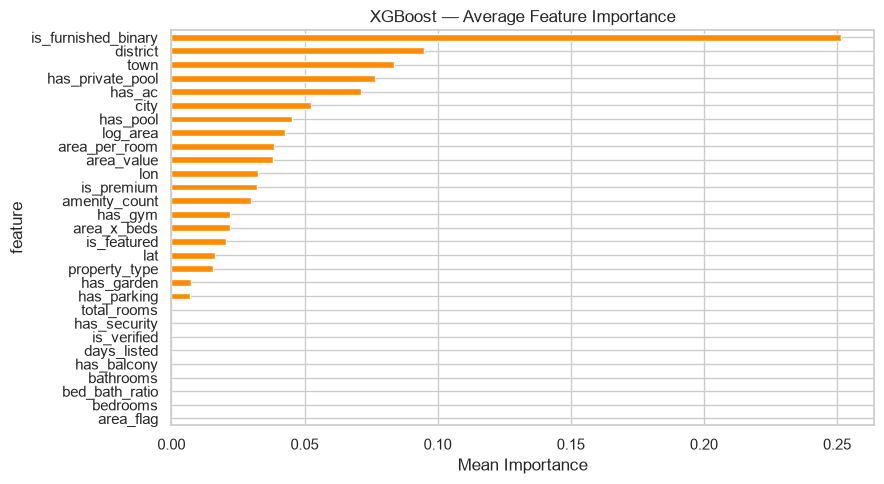

In [27]:
# Plot average XGBoost feature importance across all segments
xgb_fi = fi_df[fi_df['model'] == 'XGBoost']

if not xgb_fi.empty:
    mean_fi = xgb_fi.groupby('feature')['importance'].mean().sort_values(ascending=True)

    fig, ax = plt.subplots(figsize=(9, 5))
    mean_fi.plot(kind='barh', ax=ax, color='darkorange')
    ax.set_title('XGBoost — Average Feature Importance', fontsize=12)
    ax.set_xlabel('Mean Importance')
    plt.tight_layout()
    plt.show()